In [1]:
import sys
!{sys.executable} -m pip install seaborn

In [2]:
import sys
print(sys.executable)


c:\Users\Junha\miniconda3\envs\nba-research\python.exe


检查合并场上和场下数据后的csv 是否有逻辑问题

In [1]:
# EDA_6_VALIDATION_full_csv_level1.ipynb

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/processed/training_level1_full.csv")

print("Shape:", df.shape)
df.head()


Shape: (2082, 132)


,player_id,season,salary_usd,log_salary,salary_cap,salary_cap_ratio,log_salary_cap_ratio,salary_cap_equiv,Age,GP,...,award_NBA Eastern Conference Finals MVP,award_NBA Western Conference Finals MVP,award_Rookie of the Year,award_Sixth Man of the Year,award_Twyman-Stokes Teammate of the Year Award,award_total,injury_events,injury_unique_dates,injury_unique_categories,injury_any
0,1,2020,43006362.0,17.576859,109140000.0,0.394048,0.332212,5.539837e+07,33,63,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,2020,28751775.0,17.174210,109140000.0,0.263439,0.233838,3.703642e+07,28,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3,2020,31626953.0,17.269520,109140000.0,0.289783,0.254474,4.074006e+07,30,67,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,4,2020,29542010.0,17.201324,109140000.0,0.270680,0.239552,3.805435e+07,27,51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,2020,27528090.0,17.130718,109140000.0,0.252227,0.224924,3.546013e+07,26,61,...,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,1.0,True


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2082 entries, 0 to 2081
Columns: 132 entries, player_id to injury_any
dtypes: bool(3), float64(110), int64(10), object(9)
memory usage: 2.1+ MB


,player_id,season,salary_usd,log_salary,salary_cap,salary_cap_ratio,log_salary_cap_ratio,salary_cap_equiv,Age,GP,...,award_NBA Cup MVP,award_NBA Eastern Conference Finals MVP,award_NBA Western Conference Finals MVP,award_Rookie of the Year,award_Sixth Man of the Year,award_Twyman-Stokes Teammate of the Year Award,award_total,injury_events,injury_unique_dates,injury_unique_categories
count,2082.000000,2082.000000,2.082000e+03,2082.000000,2.082000e+03,2082.000000,2082.000000,2.082000e+03,2082.000000,2082.000000,...,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000
mean,314.918348,2022.009126,9.794686e+06,15.466561,1.244094e+08,0.078473,0.072493,1.103242e+07,26.589817,56.064841,...,0.000480,0.001441,0.001441,0.002402,0.002402,0.002402,0.109030,10.711335,10.711335,1.554275
std,244.445169,1.413334,1.104683e+07,1.213036,1.243957e+07,0.087617,0.076691,1.231790e+07,4.370058,17.203397,...,0.021916,0.037941,0.037941,0.048958,0.048958,0.048958,0.404355,16.661014,16.661014,1.884249
min,1.000000,2020.000000,5.318000e+03,8.579041,1.091400e+08,0.000047,0.000047,6.650835e+03,19.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,116.250000,2021.000000,2.068909e+06,14.542530,1.124140e+08,0.015859,0.015735,2.229609e+06,23.000000,45.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,251.000000,2022.000000,5.000000e+06,15.424949,1.236550e+08,0.040926,0.040111,5.753722e+06,26.000000,59.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,460.000000,2023.000000,1.296000e+07,16.377378,1.360000e+08,0.105310,0.100126,1.480529e+07,30.000000,70.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.750000,16.750000,3.000000
max,957.000000,2024.000000,5.576122e+07,17.836589,1.405880e+08,0.407253,0.341640,5.725492e+07,40.000000,84.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,101.000000,101.000000,10.000000


In [3]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(30)

overall_pick             0.159942
draft_is_second_round    0.159942
draft_year               0.159942
years_since_draft        0.159942
draft_is_lottery         0.159942
round                    0.159942
round_pick               0.159942
draft_is_first_round     0.159942
log_salary               0.000000
salary_usd               0.000000
season                   0.000000
player_id                0.000000
salary_cap               0.000000
salary_cap_ratio         0.000000
log_salary_cap_ratio     0.000000
salary_cap_equiv         0.000000
Age                      0.000000
GP                       0.000000
W                        0.000000
L                        0.000000
FTM                      0.000000
FTA                      0.000000
FT%                      0.000000
OREB                     0.000000
DREB                     0.000000
REB                      0.000000
AST                      0.000000
TOV                      0.000000
Min                      0.000000
PTS           

In [4]:
dupes = df.duplicated(subset=["player_id","season"]).sum()
print("Duplicated rows:", dupes)

assert dupes == 0

Duplicated rows: 0


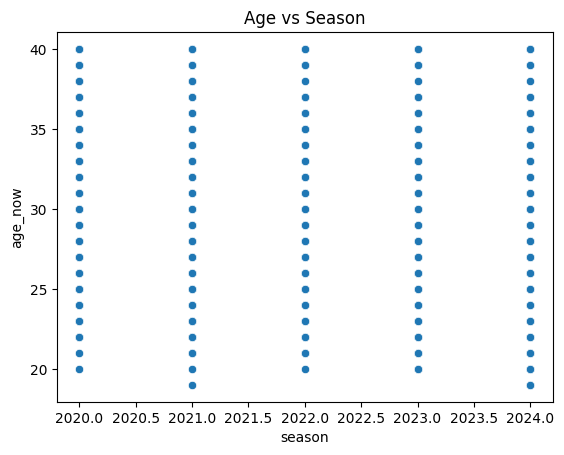

In [5]:
sns.scatterplot(data=df, x="season", y="age_now")
plt.title("Age vs Season")
plt.show()

In [6]:
df["draft_diff"] = df["season"] - df["draft_year"]
df["draft_diff"].describe()

count    1749.000000
mean        5.371069
std         4.335222
min         0.000000
25%         2.000000
50%         4.000000
75%         8.000000
max        21.000000
Name: draft_diff, dtype: float64

In [9]:
df["team_abbr"].value_counts()

team_abbr
PHI    77
DET    76
TOR    74
SAS    73
BKN    72
DAL    72
OKC    72
LAC    71
MIA    71
CHA    71
MEM    71
POR    71
PHX    71
WAS    70
CHI    70
NOP    70
CLE    69
ATL    69
UTA    68
IND    68
LAL    68
DEN    67
ORL    66
BOS    66
MIL    66
NYK    66
HOU    65
SAC    65
GSW    64
MIN    63
Name: count, dtype: int64

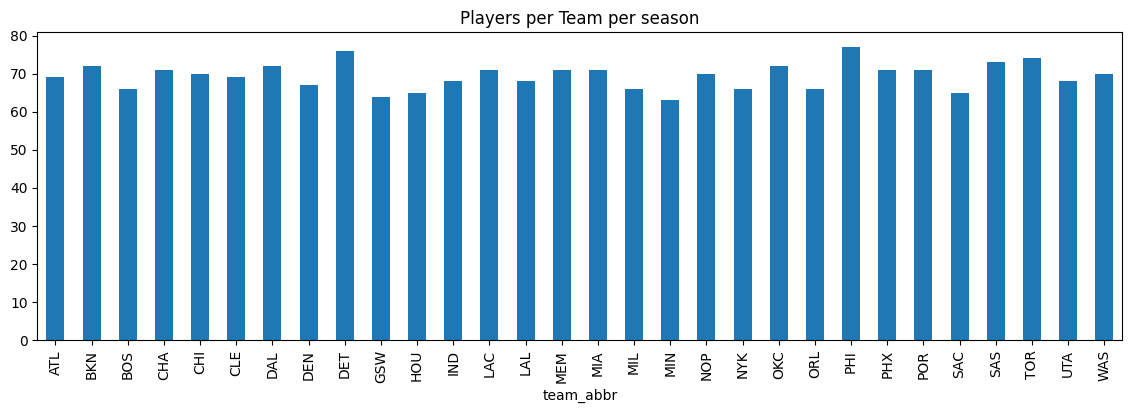

In [10]:
df.groupby("team_abbr")["player_id"].count().plot(kind="bar", figsize=(14,4))
plt.title("Players per Team per season")
plt.show()

In [11]:
award_cols = [c for c in df.columns if c.startswith("award_")]
df[award_cols].sum().sort_values(ascending=False).head()


award_total            227.0
award_All-NBA           74.0
award_All-Rookie        50.0
award_All-Defensive     48.0
award_Finals MVP         5.0
dtype: float64

In [12]:
num_df = df.select_dtypes(include="number")
corr = num_df.corr()["salary_usd"].sort_values(ascending=False)

corr.head(20)


salary_usd              1.000000
salary_cap_ratio        0.991040
salary_cap_equiv        0.991040
log_salary_cap_ratio    0.990273
log_salary              0.841866
FP                      0.726206
PTS                     0.722465
FGM                     0.713390
FGA                     0.692322
FTM                     0.662823
log1p_FGM               0.661257
log1p_PTS               0.656099
FTA                     0.647717
Min                     0.641671
log1p_FTM               0.640094
log1p_FGA               0.637950
TOV                     0.623317
log1p_FTA               0.618197
log1p_TOV               0.610487
PTS_per_min             0.591089
Name: salary_usd, dtype: float64

In [13]:
summary = {
    "missing_over_50%": missing[missing > 0.5],
    "duplicates": dupes,
    "negative_salaries": (df["salary_usd"] < 0).sum(),
    "invalid_age": (df["age_now"] < 18).sum(),
    "invalid_salary": df["salary_usd"].isna().sum(),
}

print("===== DATA VALIDATION SUMMARY =====")
summary


===== DATA VALIDATION SUMMARY =====


{'missing_over_50%': Series([], dtype: float64),
 'duplicates': np.int64(0),
 'negative_salaries': np.int64(0),
 'invalid_age': np.int64(0),
 'invalid_salary': np.int64(0)}